# **의료 이미지 데이터셋을 이용한 폐렴 진단**

CNN 모델을 활용해 Chest **X-ray Images (Pneumonia)를 정상/폐렴으로 분류**

*데이터 출처:
https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


# 라이브러리 설정

In [ ]:
#라이브러리 설치
#!pip install pydicom

import kagglehub

import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from torchvision.transforms import v2
from PIL import Image

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

# 데이터셋 파악을 위한 EDA

폴더별 계층구조로 train/test/val - 정상/폐렴 이미지가 저장된 데이터

In [ ]:
#캐글 데이터 로드
os.environ["KAGGLEHUB_CACHE"] = "."
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
#경로 확인
IMG_PATH=Path("/kaggle/input/chest-xray-pneumonia/")
print(IMG_PATH)

data_dir=os.path.join(IMG_PATH,"chest_xray")

/kaggle/input/chest-xray-pneumonia


{'train': {'normal': 1341, 'pneumonia': 3875}, 'val': {'normal': 8, 'pneumonia': 8}, 'test': {'normal': 234, 'pneumonia': 390}}


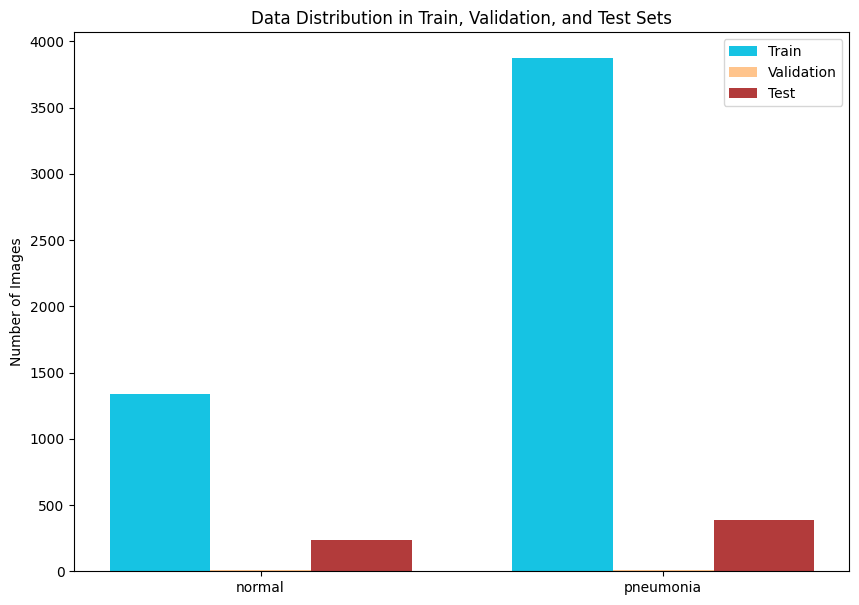

In [ ]:
#분할 및 클래스 분포 확인
splits = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']

data_distribution = {}
for split in splits:
    split_dir = os.path.join(data_dir, split)
    class_counts = {}
    for cls in classes:
        class_dir = os.path.join(split_dir, cls)
        img_count = len([img for img in os.listdir(class_dir) if img.lower().endswith(('.jpeg'))])
        class_counts[cls.lower()] = img_count
    data_distribution[split] = class_counts

print(data_distribution)

labels = ['normal', 'pneumonia']
train_counts = [data_distribution['train'][label] for label in labels]
val_counts = [data_distribution['val'][label] for label in labels]
test_counts = [data_distribution['test'][label] for label in labels]

x = range(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 7))
ax.bar([p - width for p in x], train_counts, width=width, label='Train', color='#16C3E3')
ax.bar(x, val_counts, width=width, label='Validation', color='#FFC48C')
ax.bar([p + width for p in x], test_counts, width=width, label='Test', color='#B23B3B')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Number of Images')
ax.set_title('Data Distribution in Train, Validation, and Test Sets')
ax.legend()

plt.show()

In [ ]:
#이미지 파일 크기 확인
image_sizes=[]
for img_name in os.listdir(os.path.join(data_dir,'train','NORMAL')):
    if img_name.lower().endswith(('.jpeg', '.jpg', '.png')):
        with Image.open(os.path.join(os.path.join(data_dir,'train','NORMAL'), img_name)) as img:
          image_sizes.append(img.size)

size_counts = Counter(image_sizes)
most_common_sizes = size_counts.most_common(10)
print("가장 흔한 10가지 이미지 크기와 각 개수:")
for size, count in most_common_sizes:
    print(f"{size}: {count}개")

가장 흔한 10가지 이미지 크기와 각 개수:
(1596, 1306): 2개
(1472, 1171): 2개
(1306, 994): 2개
(1778, 1356): 2개
(1558, 1279): 2개
(1268, 924): 2개
(1480, 1228): 2개
(1616, 1318): 2개
(1962, 2169): 2개
(1450, 1210): 2개


1. 폐렴 이미지가 정상보다 많은 클래스 불균형 > **데이터 증강 및 F1스코어 활용**

2. 이미지 크기 다양 > **리사이즈**

In [ ]:
#pytorch 데이터셋 클래스로 구현
class ChestXRayDataset(Dataset):
  def __init__(self,root_dir,transform=None):
    self.root_dir=root_dir
    self.transform=transform
    self.image_paths=[]
    self.labels=[]

    for label,class_name in enumerate(['NORMAL','PNEUMONIA']):
      class_dir=os.path.join(root_dir,class_name)
      for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.jpeg')):
          self.image_paths.append(os.path.join(class_dir,img_name))
          self.labels.append(label)

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self,idx):
    img_path=self.image_paths[idx]
    image=Image.open(img_path).convert('L')

    if self.transform:
      image=self.transform(image)

    label=self.labels[idx]
    return image,label


# 데이터 전처리

In [ ]:
#증강 전 원본 이미지 시각화를 위한 최소 전처리
transform_tmp=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
train_dataset_tmp=ChestXRayDataset(root_dir=os.path.join(data_dir,"train"),transform=transform_tmp)
train_loader_tmp=DataLoader(train_dataset_tmp,batch_size=4,shuffle=True)

In [ ]:
#증강 및 정규화 전처리 파이프라인
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transforms=v2.Compose([
    v2.ToImage(),
    v2.Grayscale(num_output_channels=3),
    v2.Resize(size=(224,224),antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=10),
    v2.ToDtype(torch.float32,scale=True),
    v2.Normalize(mean=imagenet_mean,std=imagenet_std),
])

test_transforms=v2.Compose([
    v2.ToImage(),
    v2.Grayscale(num_output_channels=3),
    v2.Resize((224,224),antialias=True),
    v2.ToDtype(torch.float32,scale=True),
    v2.Normalize(mean=imagenet_mean,std=imagenet_std),
])

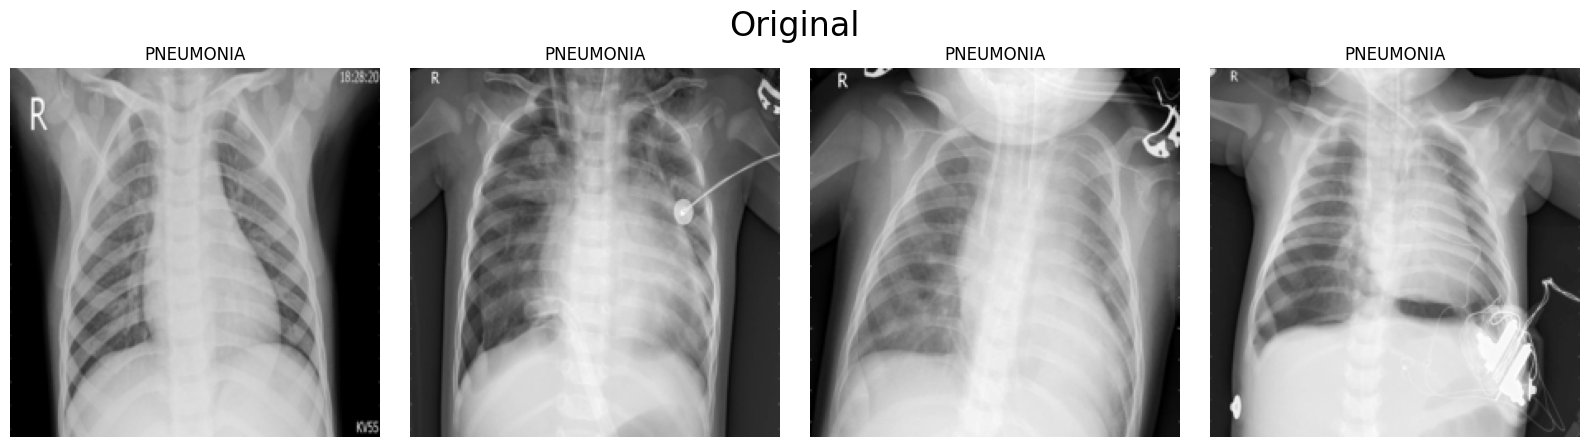

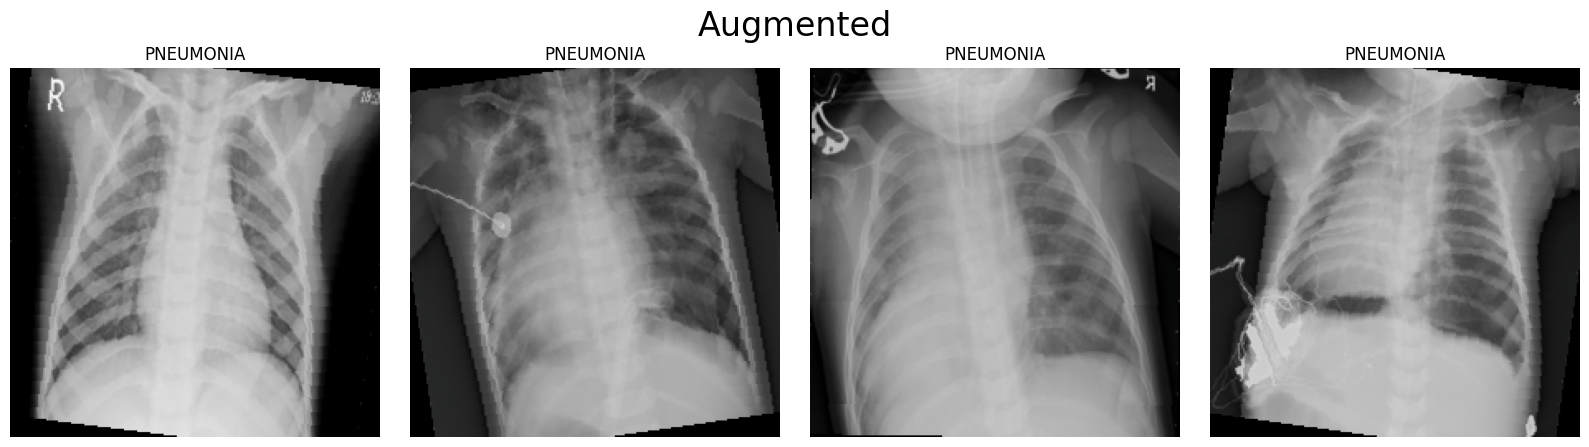

In [ ]:
#데이터 증강 전후 이미지 시각화 비교

def show_images(images,labels,title):
  n=len(images)
  fig,axes=plt.subplots(1,n,figsize=(4*n,4),constrained_layout=True)
  fig.suptitle(title,fontsize=24,y=1.08)

  if n==1:
    axes=[axes]

  for i,ax in enumerate(axes):
    img=images[i]
    if img.ndim == 3 and img.shape[0] == 3:
      img = np.transpose(img.numpy(), (1, 2, 0))
      img = img * np.array(imagenet_std) + np.array(imagenet_mean)
      img = np.clip(img, 0, 1)
    else:
      img = img.squeeze().numpy()
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    ax.set_title(f'{"PNEUMONIA" if labels[i] else "NORMAL"}')
    ax.axis('off')
  plt.show()

original_images=[]
original_labels=[]
for i,(img,label) in enumerate(train_loader_tmp):
  if i==1:
    break
  for j in range(img.size(0)):
    original_images.append(img[j])
    original_labels.append(label[j].item())

augmented_images=[
    train_transforms(Image.fromarray((img.squeeze().numpy()*255).astype('uint8')))
    for img in original_images
]

show_images(original_images,original_labels,"Original")
show_images(augmented_images,original_labels,"Augmented")

# 모델 설계

사전 학습된 ResNet18 모델을 기반으로 제한된 데이터셋에 성능 향상

pre_conv를 통해 의료 이미지에 맞는 초기 특징 추출

과적합 방지 장치 포함

In [ ]:
#cnn 모델 구축
class PneumoniaResNet(nn.Module):
  def __init__(self,pretrained=True):
    super(PneumoniaResNet,self).__init__()
    self.pre_conv = nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.Conv2d(16, 3, kernel_size=3, padding=1),
        nn.BatchNorm2d(3),
        nn.ReLU(),
    )
    self.model = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
    num_ftrs = self.model.fc.in_features
    self.model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, 1)
    )

  def forward(self,x):
    x=self.pre_conv(x)
    x=self.model(x)
    return x.squeeze(1)


하이퍼파라미터

*   정상/폐렴 이진 분류에 적합한 sigmoid와 binary cross entropy 결합 함수 활용
*   전이학습에 맞춰 작은 learning rate 설정
*   데이터가 적고 사전학습 가중치를 활용해 epoch 15로 설정
*   val_loss가 2 epoch 동안 개선되지 않으면 learning rate를 50% 줄여 학습 정체 완화





In [ ]:
#하이퍼파라미터 및 장치 설정
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model=PneumoniaResNet().to(device)
criterion=nn.BCEWithLogitsLoss()
optimizer=optim.Adam(model.parameters(),lr=0.0001)
num_epochs=15

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


# 학습

In [ ]:
#데이터로더 준비
train_dataset=ChestXRayDataset(root_dir=os.path.join(data_dir,"train"),transform=train_transforms)
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True,num_workers=2)

val_dataset=ChestXRayDataset(root_dir=os.path.join(data_dir,"val"),transform=test_transforms)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=False,num_workers=2)

test_dataset=ChestXRayDataset(root_dir=os.path.join(data_dir,"test"),transform=test_transforms)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False,num_workers=2)

In [ ]:
#학습 루프

#**런타임 30분 예상

train_losses=[]
train_accuracies=[]
val_losses=[]
val_accuracies=[]


for epoch in range(num_epochs):
  model.train()
  train_loss=0.0
  train_correct=0

  for images,labels in train_loader:
    images,labels=images.to(device),labels.float().to(device)

    outputs=model(images)
    loss=criterion(outputs,labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss+=loss.item()*images.size(0)
    preds=(torch.sigmoid(outputs)>=0.5).long()
    train_correct+=torch.sum(preds==labels.data)

  train_epoch_loss=train_loss/len(train_loader.dataset)
  train_epoch_acc=train_correct.double()/len(train_loader.dataset)

  train_losses.append(train_epoch_loss)
  train_accuracies.append(train_epoch_acc.item())

  print(f"[Train] Loss : {train_epoch_loss:.4f} Acc: {train_epoch_acc:.4f}")

  with torch.no_grad():
    model.eval()
    val_loss=0.0
    val_correct=0.0
    for images,labels in val_loader:
      images,labels=images.to(device),labels.float().to(device)
      outputs=model(images)
      loss=criterion(outputs,labels)

      val_loss+=loss.item()*images.size(0)
      preds=(torch.sigmoid(outputs)>=0.5).long()
      val_correct+=torch.sum(preds==labels.data)

    val_epoch_loss=val_loss/len(val_loader.dataset)
    val_epoch_acc=val_correct.double()/len(val_loader.dataset)

    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc.item())

    scheduler.step(val_epoch_loss)

    print(f"[Val] Loss : {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")



[Train] Loss : 0.2699 Acc: 0.9275
[Val] Loss : 0.4132 Acc: 0.8125
[Train] Loss : 0.1530 Acc: 0.9734
[Val] Loss : 0.3875 Acc: 0.7500
[Train] Loss : 0.1129 Acc: 0.9781
[Val] Loss : 0.4920 Acc: 0.6250
[Train] Loss : 0.0759 Acc: 0.9883
[Val] Loss : 0.2798 Acc: 0.8750
[Train] Loss : 0.0743 Acc: 0.9833
[Val] Loss : 0.6171 Acc: 0.6250
[Train] Loss : 0.0589 Acc: 0.9868
[Val] Loss : 0.1442 Acc: 0.9375
[Train] Loss : 0.0593 Acc: 0.9845
[Val] Loss : 0.7718 Acc: 0.6250
[Train] Loss : 0.0422 Acc: 0.9902
[Val] Loss : 0.0496 Acc: 1.0000
[Train] Loss : 0.0418 Acc: 0.9906
[Val] Loss : 0.1191 Acc: 1.0000
[Train] Loss : 0.0346 Acc: 0.9895
[Val] Loss : 0.0628 Acc: 1.0000
[Train] Loss : 0.0287 Acc: 0.9935
[Val] Loss : 0.0956 Acc: 1.0000
[Train] Loss : 0.0224 Acc: 0.9946
[Val] Loss : 0.2284 Acc: 0.8750
[Train] Loss : 0.0158 Acc: 0.9973
[Val] Loss : 0.7302 Acc: 0.6875
[Train] Loss : 0.0143 Acc: 0.9979
[Val] Loss : 0.1442 Acc: 0.9375
[Train] Loss : 0.0143 Acc: 0.9975
[Val] Loss : 0.1422 Acc: 0.9375


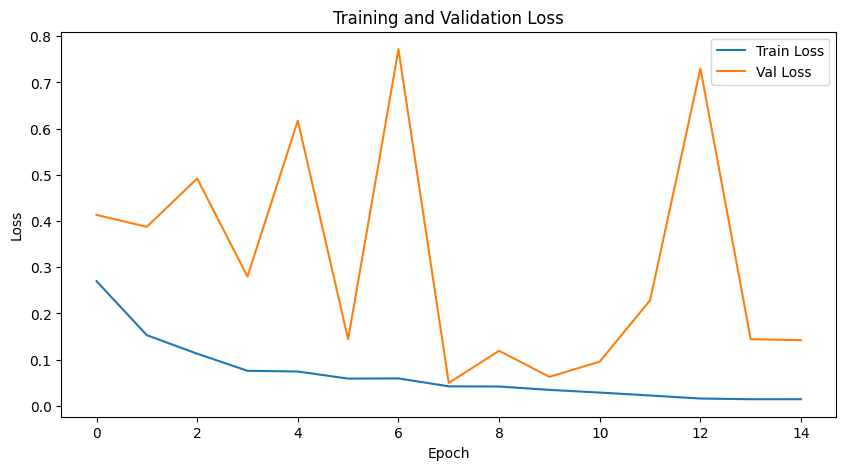

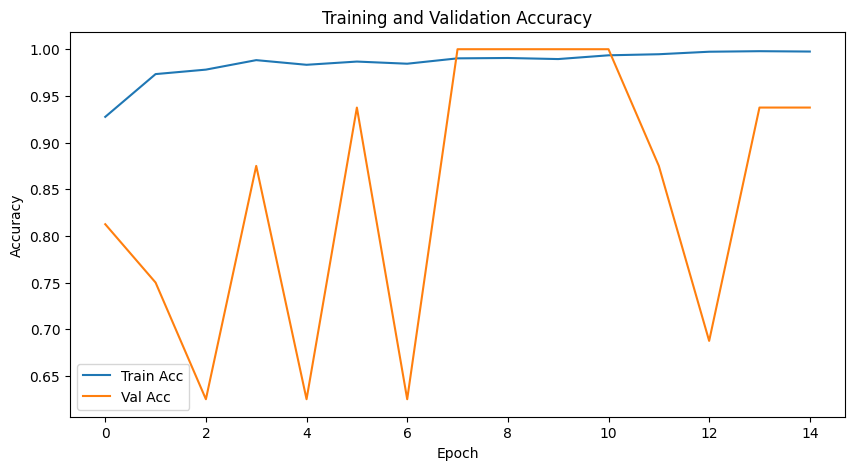

In [ ]:
#학습 과정 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# 학습 결과 확인

특정 클래스로 예측값이 치중했는지 확인

In [ ]:
#예측값 분포 확인
from collections import Counter

model.eval()
all_preds = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs >= 0.5).long().cpu().numpy()
        all_preds.extend(np.array(preds).flatten())
print("Test prediction distribution:", Counter(all_preds))


Test prediction distribution: Counter({np.int64(1): 507, np.int64(0): 117})


# 평가 및 최적 모델 선정

임계값 별로 accuracy, precision, recall, F1, AUROC 계산

In [ ]:
#평가 함수 정의
def evaluate_pneumonia_metrics(model, test_loader, device,thresholds=[0.5],class_names=['Normal','Pneumonia']):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).view(-1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy().reshape(-1))

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    #print(f"전체 test 샘플 수: {len(all_labels)} (test set 크기: {len(test_loader.dataset)})")

    preds_dict={}
    metrics_dict={}

    for threshold in thresholds:
        preds = (all_probs >= threshold).astype(int)
        preds_dict[threshold]=preds.copy()

        #print(f"len(all_labels): {len(all_labels)}, len(preds): {len(preds)}")

        accuracy = accuracy_score(all_labels, preds)
        precision = precision_score(all_labels, preds,zero_division=0)
        recall = recall_score(all_labels, preds,zero_division=0)
        f1 = f1_score(all_labels, preds,zero_division=0)
        try:
          auroc = roc_auc_score(all_labels, all_probs)
        except ValueError:
          auroc = float('nan')

        metrics_dict[threshold]={
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'AUROC': auroc
    }

    return metrics_dict,all_labels,preds_dict,all_probs


,Accuracy,Precision,Recall,F1 Score,AUROC
Threshold,,,,,
0.3,0.791667,0.750965,0.997436,0.856828,0.86184
0.5,0.806090,0.765286,0.994872,0.865106,0.86184
0.7,0.823718,0.782258,0.994872,0.875847,0.86184


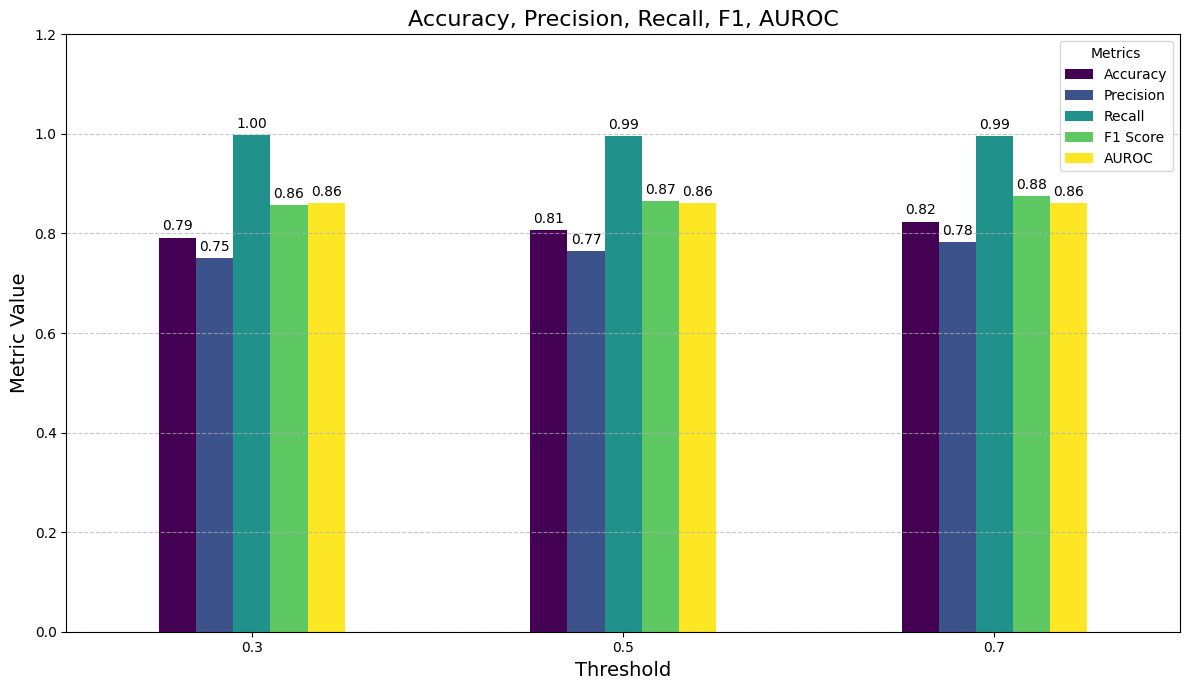

최적 임계값(F1 Score 기준): 0.7


In [ ]:
#최적의 임계값 선택
thresholds = [0.3, 0.5, 0.7]
metrics_dict,all_labels,preds_dict,all_probs=evaluate_pneumonia_metrics(model,test_loader,device,thresholds=thresholds)

results_df = pd.DataFrame(metrics_dict).T
results_df.index.name = 'Threshold'
display(results_df)

ax = results_df.plot(kind='bar', figsize=(12, 7), colormap='viridis')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3), textcoords='offset points')

ax.set_title('Accuracy, Precision, Recall, F1, AUROC', fontsize=16)
ax.set_xlabel('Threshold', fontsize=14)
ax.set_ylabel('Metric Value', fontsize=14)
ax.legend(title='Metrics')
ax.set_ylim(0, 1.2)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

best_threshold = results_df['F1 Score'].idxmax()
print(f"최적 임계값(F1 Score 기준): {best_threshold}")


클래스 불균형 데이터이므로 F1 score가 가장 높은 임계값 선택


[최종 평가 결과] (임계값=0.7)


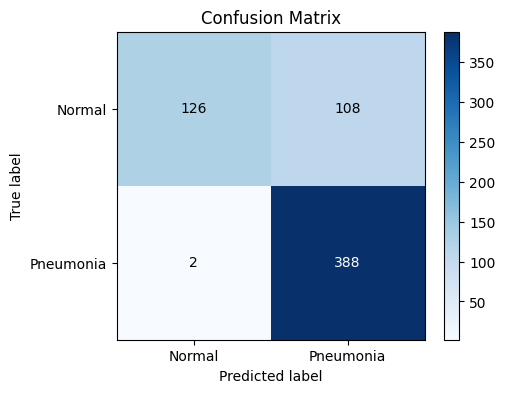

,Accuracy,Precision,Recall,F1 Score,AUROC
0.7,0.823718,0.782258,0.994872,0.875847,0.86184


모델이 'best_pneumonia_model.pth'에 저장되었습니다.


In [ ]:
#혼동행렬 시각화 및 모델 저장

def plot_confusion_matrix(y_true, y_pred, class_names=['Normal', 'Pneumonia']):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=class_names, yticklabels=class_names,
        ylabel='True label',
        xlabel='Predicted label',
        title='Confusion Matrix'
    )
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.show()


print(f"\n[최종 평가 결과] (임계값={best_threshold})")
plot_confusion_matrix(all_labels, preds_dict[best_threshold], class_names=['Normal','Pneumonia'])

final_metrics = results_df.loc[best_threshold]
display(final_metrics.to_frame().T)

def save_model(model, path='best_pneumonia_model.pth'):
    torch.save(model.state_dict(), path)
    print(f"모델이 '{path}'에 저장되었습니다.")

save_model(model)

# **결과 보고**
---


*   모델은 테스트 셋에서 정확도 82.4% 성능 보임
*   임계값을 0.3,0.5,0.7로 변경하여 평가한 결과, 해당 모델의 F1 score가 가장 높았음
*   혼동행렬 시각화 결과, 의료 분야에서 치명적인 2종 오류(실제 폐렴인데 정상으로 오진)가 최소화



---







# 폐렴 예측 및 시각화

예측한 10개 이미지의 정확도: 90.0%


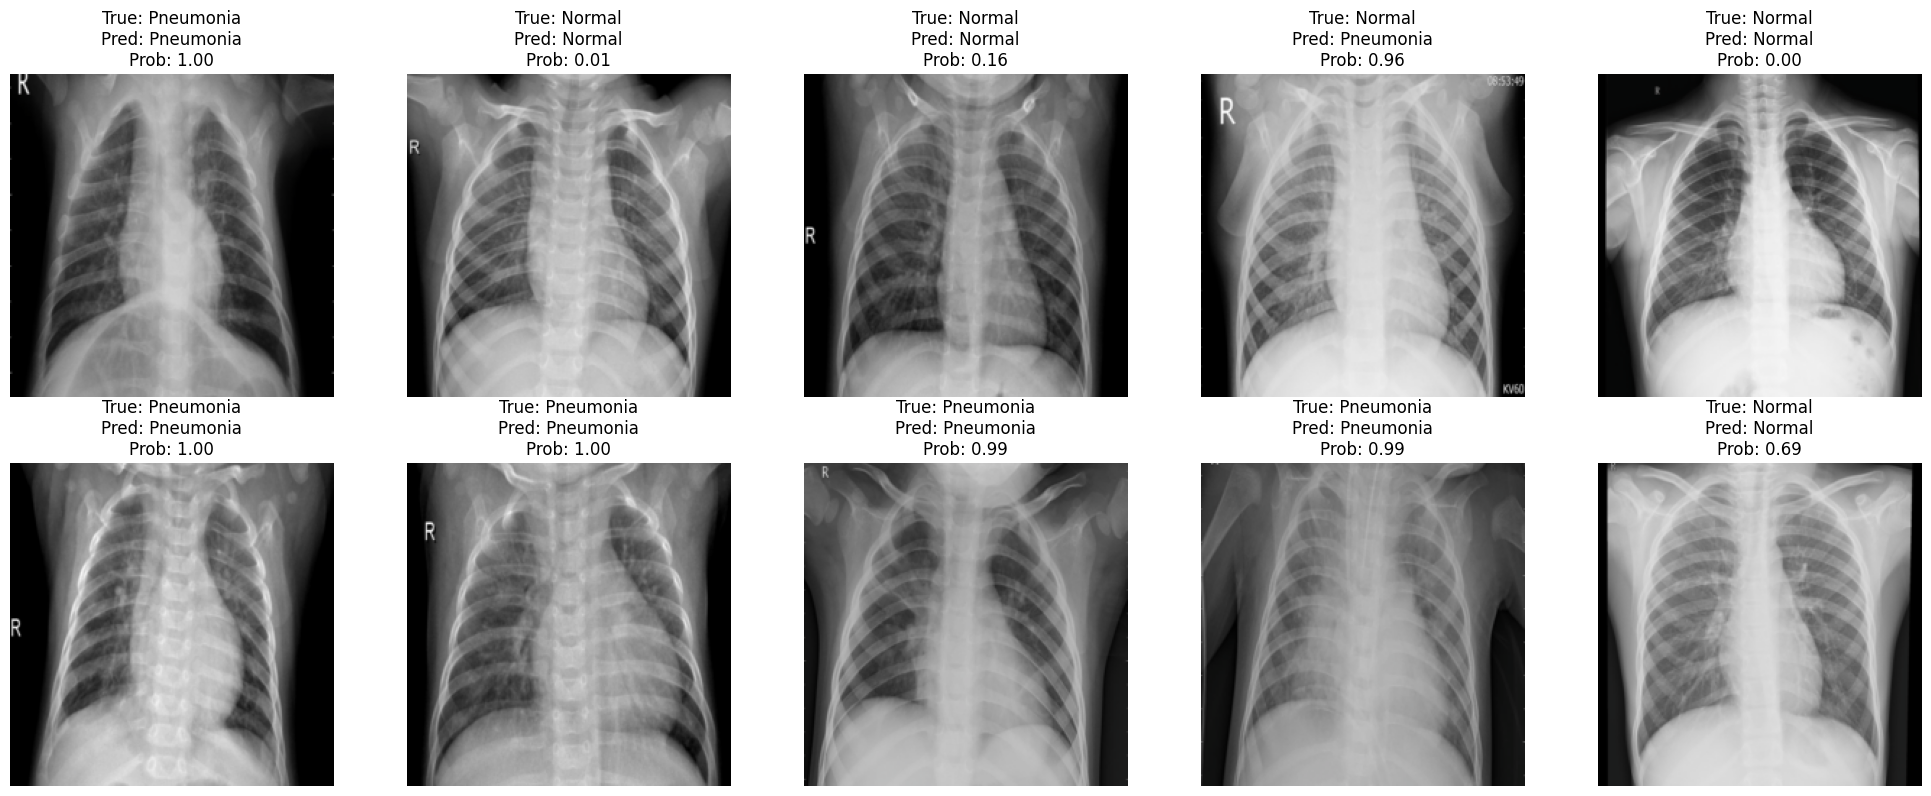

In [ ]:
#테스트셋에서 랜덤하게 이미지를 뽑아 모델로 예측
def visualize_test_predictions_mixed(model, test_loader, device, num_images=8, threshold=0.5):
    model.eval()
    images_all = []
    labels_all = []

    for images, labels in test_loader:
        images_all.append(images)
        labels_all.append(labels)
    images_all = torch.cat(images_all, dim=0)
    labels_all = torch.cat(labels_all, dim=0)

    normal_indices = (labels_all == 0).nonzero(as_tuple=True)[0].cpu().numpy()
    pneumonia_indices = (labels_all == 1).nonzero(as_tuple=True)[0].cpu().numpy()

    num_each = num_images // 2
    np.random.seed(42)
    selected_normal = np.random.choice(normal_indices, num_each, replace=False)
    selected_pneumonia = np.random.choice(pneumonia_indices, num_each, replace=False)

    selected_indices = np.concatenate([selected_normal, selected_pneumonia])
    np.random.shuffle(selected_indices)

    selected_images = images_all[selected_indices].to(device)
    selected_labels = labels_all[selected_indices].cpu().numpy()

    with torch.no_grad():
        outputs = model(selected_images)
        probs = torch.sigmoid(outputs).cpu().numpy().squeeze()

    preds = (probs >= threshold).astype(int)

    accuracy = np.mean(preds == selected_labels)
    print(f"예측한 {num_images}개 이미지의 정확도: {accuracy*100:.1f}%")

    mean = np.array(imagenet_mean).reshape(3, 1, 1)
    std = np.array(imagenet_std).reshape(3, 1, 1)
    denorm_images = selected_images.cpu().numpy() * std + mean
    denorm_images = np.clip(denorm_images, 0, 1)

    fig, axes = plt.subplots(2, num_images//2, figsize=(20, 8))
    axes = axes.flatten()

    for i in range(num_images):
        img = denorm_images[i].transpose(1, 2, 0)
        axes[i].imshow(img)
        axes[i].set_title(f"True: {'Pneumonia' if selected_labels[i] else 'Normal'}\n"
                          f"Pred: {'Pneumonia' if preds[i] else 'Normal'}\n"
                          f"Prob: {probs[i]:.2f}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

visualize_test_predictions_mixed(model, test_loader, device, num_images=10, threshold=best_threshold)
